# AlphaGo Zero — Actor-Critic with Monte Carlo Tree Search

This notebook implements the core ideas of the **AlphaGo Zero** paper
(*Silver et al., 2017 — "Mastering the game of Go without human knowledge"*)
on a tractable toy problem: **Tic-Tac-Toe**.

AlphaGo Zero replaced handcrafted features, separate policy/value networks, and
rollout policies with a single dual-headed neural network trained entirely from
self-play.  MCTS serves as the *policy improvement operator*: it uses the
network to guide search, and the search result is then used to supervise the
network.

**Environment:** Tic-Tac-Toe (3 × 3).  **Runtime:** ≈ 3–6 min on CPU.

## Outline

| # | Section | Key idea |
|---|---------|----------|
| 1 | Environment | Tic-Tac-Toe dynamics and canonical board representation |
| 2 | Pure MCTS | UCT selection, random rollouts, backpropagation |
| 3 | Dual Network | Policy head + value head sharing a common trunk |
| 4 | AlphaGo Zero MCTS | PUCT selection, network evaluation instead of rollouts |
| 5 | Self-play training | Generating data, cross-entropy + MSE loss |
| 6 | Evaluation | Network-guided MCTS vs pure random MCTS |
| 7 | Summary | Design choices and connection to broader AlphaGo family |

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math
import random
import copy
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

def smooth(x, w=20):
    if len(x) < w:
        return np.array(x)
    return np.convolve(x, np.ones(w) / w, mode='valid')

## 1 — Environment: Tic-Tac-Toe

The board is a 3 × 3 grid.  Player **+1** and player **−1** alternate placing
marks; the player who completes a row, column, or diagonal wins.

We represent the state as a flat NumPy array of length 9 with values in
{−1, 0, +1}, where 0 = empty, +1 = current player's mark, −1 = opponent.

**Canonical convention:** the board is always stored from the perspective of the
player *about to move*.  After each move we negate the board, so the active
player is always +1.  This lets the same network evaluate positions for both
players without any modification.

In [2]:
class TicTacToe:
    """Tic-Tac-Toe with canonical (current-player-always-+1) board."""

    WINS = [
        [0, 1, 2], [3, 4, 5], [6, 7, 8],  # rows
        [0, 3, 6], [1, 4, 7], [2, 5, 8],  # cols
        [0, 4, 8], [2, 4, 6],             # diagonals
    ]

    def __init__(self):
        self.board = np.zeros(9, dtype=np.float32)  # 0=empty, +1=current, -1=opponent
        self.done = False
        self.winner = 0  # +1 = current player won (at time of win), -1 = lost, 0 = draw

    def copy(self):
        env = TicTacToe.__new__(TicTacToe)
        env.board = self.board.copy()
        env.done = self.done
        env.winner = self.winner
        return env

    def legal_moves(self):
        return np.where(self.board == 0)[0].tolist()

    def _check_winner(self, player):
        for line in self.WINS:
            if all(self.board[i] == player for i in line):
                return True
        return False

    def step(self, action):
        """Place current player's mark (+1) at `action`, then flip board.

        Returns (reward, done) from the perspective of the player who just moved.
        reward: +1 = win, -1 = loss, 0 = draw or game continues.
        """
        assert self.board[action] == 0 and not self.done, "Illegal move"
        self.board[action] = 1.0

        if self._check_winner(1):
            self.done = True
            self.winner = 1
            self.board = -self.board  # flip for consistency
            return 1.0, True

        if not self.legal_moves():  # after flip check, but before flip
            self.done = True
            self.winner = 0
            self.board = -self.board
            return 0.0, True

        # Game continues — flip board so next player is +1
        self.board = -self.board
        return 0.0, False

    def render(self):
        sym = {1.0: 'X', -1.0: 'O', 0.0: '.'}
        for r in range(3):
            print(' '.join(sym[self.board[r * 3 + c]] for c in range(3)))
        print()


# Quick sanity check
env = TicTacToe()
for move in [4, 0, 1, 3, 7]:   # player +1 tries centre, corners; player -1 blocks
    r, done = env.step(move)
    if done:
        print(f'Game over, reward for last player: {r}')
        break
env.render()

Game over, reward for last player: 1.0
X O .
X O .
. O .



## 2 — Pure MCTS

Monte Carlo Tree Search builds a search tree incrementally.  Each node stores:

| Symbol | Meaning |
|--------|---------|
| $N(s,a)$ | Visit count for action $a$ from state $s$ |
| $W(s,a)$ | Total value accumulated through $(s,a)$ |
| $Q(s,a) = W(s,a)/N(s,a)$ | Mean action value |

Each MCTS iteration has four phases:

1. **Selection** — traverse the tree greedily by $\text{UCT}$:
$$a^* = \arg\max_a \left[ Q(s,a) + c \sqrt{\frac{\ln N(s)}{N(s,a)}} \right]$$
   The second term is an *exploration bonus* that decays as $N(s,a)$ grows.

2. **Expansion** — when a leaf is reached, add its children to the tree.

3. **Simulation** — play out a random game from the new node.

4. **Backpropagation** — update $N$ and $W$ along the path to the root,
   flipping the sign of the value at each level (zero-sum game).

In [3]:
class MCTSNode:
    """A node in the MCTS tree."""

    def __init__(self, env: TicTacToe, parent=None, action=None):
        self.env = env          # board state at this node
        self.parent = parent
        self.action = action    # action taken from parent to reach here
        self.children = {}      # action -> MCTSNode
        self.N = 0              # visit count
        self.W = 0.0            # total value
        self._untried = env.legal_moves() if not env.done else []
        random.shuffle(self._untried)

    @property
    def Q(self):
        return self.W / self.N if self.N > 0 else 0.0

    def is_fully_expanded(self):
        return len(self._untried) == 0

    def uct_child(self, c=1.41):
        """Select child with highest UCT score."""
        log_N = math.log(self.N)
        return max(
            self.children.values(),
            key=lambda ch: ch.Q + c * math.sqrt(log_N / (ch.N + 1e-8))
        )

    def expand(self):
        """Expand one untried action and return the new child."""
        action = self._untried.pop()
        child_env = self.env.copy()
        child_env.step(action)
        child = MCTSNode(child_env, parent=self, action=action)
        self.children[action] = child
        return child


def random_rollout(env: TicTacToe) -> float:
    """Play out a random game; return +1/0/-1 from the perspective of
    the player whose turn it was at `env`."""
    env = env.copy()
    flip = 1  # tracks perspective relative to original env
    while not env.done:
        action = random.choice(env.legal_moves())
        reward, done = env.step(action)
        flip *= -1
        if done:
            # reward is from the player who just moved; flip back to root perspective
            return reward * flip
    return 0.0


def mcts(root_env: TicTacToe, n_simulations: int = 200, c: float = 1.41) -> np.ndarray:
    """Run pure MCTS from `root_env` and return a visit-count policy over 9 actions."""
    root = MCTSNode(root_env)

    for _ in range(n_simulations):
        node = root
        # 1. Selection
        while not node.env.done and node.is_fully_expanded():
            node = node.uct_child(c)
        # 2. Expansion
        if not node.env.done and not node.is_fully_expanded():
            node = node.expand()
        # 3. Simulation
        if node.env.done:
            value = node.env.winner  # +1 or 0 for the player who just finished
            # The winner is stored as +1 for the player who moved *last*,
            # which is the *opponent* of the current node's perspective.
            value = -value  # flip to node's perspective
        else:
            value = random_rollout(node.env)
        # 4. Backpropagation
        sign = 1
        while node is not None:
            node.N += 1
            node.W += value * sign
            sign *= -1  # flip at each level (zero-sum)
            node = node.parent

    # Build policy from visit counts
    policy = np.zeros(9)
    for action, child in root.children.items():
        policy[action] = child.N
    if policy.sum() > 0:
        policy /= policy.sum()
    return policy


# Demo: MCTS selects the winning move
env = TicTacToe()
# X (player +1) has marks at 0,1; plays 2 to win
env.board = np.array([1, 1, 0, -1, -1, 0, 0, 0, 0], dtype=np.float32)
policy = mcts(env, n_simulations=400)
print('Board:')
env.render()
print('MCTS visit-count policy:')
print(policy.reshape(3, 3).round(3))
print(f'Best action: {policy.argmax()} (should be 2 — completes top row)')

Board:
X X .
O O .
. . .

MCTS visit-count policy:
[[0.    0.    0.018]
 [0.    0.    0.118]
 [0.228 0.33  0.308]]
Best action: 7 (should be 2 — completes top row)


## 3 — Dual Network: Policy Head + Value Head

AlphaGo Zero replaces random rollouts with a neural network $f_\theta$ that
simultaneously predicts:

$$f_\theta(s) = (\mathbf{p}, v)$$

- **Policy head** $\mathbf{p} \in \Delta^{|A|}$: a prior probability over moves,
  encoding the network's *first guess* at good actions.
- **Value head** $v \in [-1, 1]$: the expected game outcome from state $s$
  under self-play.

The two heads share a common feature trunk (a stack of residual blocks in the
full paper; a small MLP here).  The input is a canonical board tensor with
three planes:

| Plane | Content |
|-------|---------|
| 0 | Current player's pieces (+1 where present) |
| 1 | Opponent's pieces (+1 where present) |
| 2 | All-ones (bias plane) |

The **actor-critic** connection: the policy head is the *actor* (outputs
a distribution over actions) and the value head is the *critic* (evaluates the
current state).  In standard A2C the critic bootstraps TD targets; here MCTS
supplies the policy targets and self-play outcomes supply the value targets.

In [4]:
def board_to_tensor(board: np.ndarray) -> torch.Tensor:
    """Convert a flat board (9,) -> tensor (1, 3, 3, 3) with 3 planes."""
    cur  = (board  > 0).astype(np.float32)   # current player
    opp  = (board  < 0).astype(np.float32)   # opponent
    bias = np.ones(9, dtype=np.float32)       # constant bias plane
    planes = np.stack([cur, opp, bias], axis=0).reshape(3, 3, 3)
    return torch.from_numpy(planes).unsqueeze(0)  # (1, 3, 3, 3)


class ResBlock(nn.Module):
    """Minimal 2-layer residual block (conv → BN → ReLU → conv → BN + skip)."""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(channels)

    def forward(self, x):
        h = F.relu(self.bn1(self.conv1(x)))
        h = self.bn2(self.conv2(h))
        return F.relu(h + x)


class AlphaGoNet(nn.Module):
    """
    Dual-headed network: shared trunk → policy head + value head.

    Input : (B, 3, 3, 3)  — three feature planes over 3×3 board
    Policy: (B, 9)        — log-probabilities over 9 actions
    Value : (B,)          — scalar in (-1, 1)
    """

    def __init__(self, channels=32, n_res=2):
        super().__init__()
        # Trunk
        self.stem = nn.Sequential(
            nn.Conv2d(3, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
        )
        self.res_blocks = nn.Sequential(*[ResBlock(channels) for _ in range(n_res)])

        # Policy head
        self.policy_conv = nn.Conv2d(channels, 2, 1, bias=False)
        self.policy_bn   = nn.BatchNorm2d(2)
        self.policy_fc   = nn.Linear(2 * 9, 9)

        # Value head
        self.value_conv = nn.Conv2d(channels, 1, 1, bias=False)
        self.value_bn   = nn.BatchNorm2d(1)
        self.value_fc1  = nn.Linear(9, 64)
        self.value_fc2  = nn.Linear(64, 1)

    def forward(self, x):
        h = self.res_blocks(self.stem(x))        # (B, C, 3, 3)

        # Policy
        p = F.relu(self.policy_bn(self.policy_conv(h)))
        p = p.view(p.size(0), -1)               # (B, 18)
        log_p = F.log_softmax(self.policy_fc(p), dim=-1)  # (B, 9)

        # Value
        v = F.relu(self.value_bn(self.value_conv(h)))
        v = v.view(v.size(0), -1)               # (B, 9)
        v = F.relu(self.value_fc1(v))
        v = torch.tanh(self.value_fc2(v)).squeeze(-1)  # (B,)

        return log_p, v

    @torch.no_grad()
    def predict(self, board: np.ndarray):
        """Return (policy probs array, value scalar) for a single board."""
        self.eval()
        x = board_to_tensor(board)
        log_p, v = self(x)
        return log_p.exp().cpu().numpy().squeeze(0), v.item()


# Verify shapes
net = AlphaGoNet()
dummy = torch.zeros(4, 3, 3, 3)
lp, val = net(dummy)
print('Policy log-probs shape:', lp.shape)   # (4, 9)
print('Value shape           :', val.shape)  # (4,)

Policy log-probs shape: torch.Size([4, 9])
Value shape           : torch.Size([4])


## 4 — AlphaGo Zero MCTS

Two changes from pure MCTS make it *network-guided*:

**1. PUCT selection** (Predictor + UCT):

$$a^* = \arg\max_a \left[ Q(s,a) + c_{\text{puct}} \cdot P(s,a) \cdot \frac{\sqrt{N(s)}}{1 + N(s,a)} \right]$$

where $P(s,a)$ is the **policy prior** from the network.  Compared to
UCT, the exploration bonus now scales with the network's confidence rather than
purely with visit counts.

**2. Network evaluation instead of rollouts:**
When a new leaf is expanded the network provides both:
- The **prior** $P(s,\cdot)$ for all children (used in PUCT)
- The **leaf value** $v$ (used instead of a random rollout)

This removes the variance from random simulations entirely.

**Training targets from MCTS:**
After running $N$ simulations from root $s$, the empirical visit-count distribution
$$\pi(a|s) = N(s,a)^{1/\tau} \big/ \sum_{a'} N(s,a')^{1/\tau}$$
is a *better* policy than the raw network output (MCTS improves the policy).
The network is then trained to predict $(\pi, z)$ where $z \in \{-1, 0, 1\}$
is the game outcome from self-play:

$$\mathcal{L} = \underbrace{-\sum_a \pi(a) \log p_\theta(a|s)}_{\text{policy loss}} + \underbrace{(z - v_\theta(s))^2}_{\text{value loss}} + \lambda \|\theta\|^2$$

This is exactly the **actor-critic loss**: the policy head is trained by the
MCTS-improved policy (the *actor* is supervised by a better expert), and the
value head regresses on game outcomes (the *critic*).

In [5]:
class AZNode:
    """MCTS node for AlphaGo Zero (stores prior P from network)."""

    def __init__(self, env: TicTacToe, prior: float = 0.0,
                 parent=None, action=None):
        self.env    = env
        self.prior  = prior   # P(s, a) from the policy network
        self.parent = parent
        self.action = action
        self.children = {}    # action -> AZNode
        self.N = 0
        self.W = 0.0

    @property
    def Q(self):
        return self.W / self.N if self.N > 0 else 0.0

    def is_leaf(self):
        return len(self.children) == 0

    def puct_score(self, c_puct: float) -> float:
        """U(s,a) = c_puct * P(s,a) * sqrt(N(parent)) / (1 + N(s,a))."""
        U = c_puct * self.prior * math.sqrt(self.parent.N) / (1 + self.N)
        return self.Q + U

    def best_child(self, c_puct: float):
        return max(self.children.values(), key=lambda ch: ch.puct_score(c_puct))


def az_mcts(
    root_env: TicTacToe,
    net: AlphaGoNet,
    n_simulations: int = 200,
    c_puct: float = 1.0,
    temperature: float = 1.0,
    add_noise: bool = False,   # Dirichlet noise at root for exploration during training
    noise_alpha: float = 0.3,
    noise_eps: float = 0.25,
) -> np.ndarray:
    """Run AlphaGo Zero MCTS; return visit-count policy over 9 actions."""

    root = AZNode(root_env)

    # Initialise root by evaluating with the network
    priors, _ = net.predict(root_env.board)
    if add_noise:
        noise = np.random.dirichlet([noise_alpha] * 9)
        priors = (1 - noise_eps) * priors + noise_eps * noise
    # Mask illegal moves
    legal = root_env.legal_moves()
    mask = np.zeros(9)
    mask[legal] = 1
    priors = priors * mask
    if priors.sum() > 1e-8:
        priors /= priors.sum()
    else:
        priors = mask / mask.sum()
    for a in legal:
        child_env = root_env.copy()
        child_env.step(a)
        root.children[a] = AZNode(child_env, prior=float(priors[a]),
                                   parent=root, action=a)
    root.N = 1  # count root visit for PUCT denominator

    for _ in range(n_simulations):
        node = root

        # 1. Selection — descend until we hit a leaf or terminal
        while not node.is_leaf() and not node.env.done:
            node = node.best_child(c_puct)

        # 2. Expansion + Evaluation
        if node.env.done:
            # Terminal: value is the outcome for the player who just moved
            # The board was flipped after the move, so winner is stored as +1
            # for the mover; from *this* node's perspective (= opponent of mover)
            # the value is -winner.
            value = -float(node.env.winner)
        else:
            # Leaf — evaluate with network and expand
            priors, value = net.predict(node.env.board)
            legal = node.env.legal_moves()
            mask = np.zeros(9)
            mask[legal] = 1
            priors = priors * mask
            s = priors.sum()
            priors = priors / s if s > 1e-8 else mask / mask.sum()
            for a in legal:
                child_env = node.env.copy()
                child_env.step(a)
                node.children[a] = AZNode(child_env, prior=float(priors[a]),
                                           parent=node, action=a)

        # 3. Backpropagation
        sign = 1
        while node is not None:
            node.N += 1
            node.W += value * sign
            sign *= -1
            node = node.parent

    # Build policy from visit counts
    counts = np.array([root.children[a].N if a in root.children else 0
                       for a in range(9)], dtype=np.float64)
    if temperature == 0 or counts.sum() == 0:
        policy = np.zeros(9)
        policy[counts.argmax()] = 1.0
    else:
        counts_t = counts ** (1.0 / temperature)
        policy = counts_t / counts_t.sum()
    return policy


# Demo: untrained network still finds the winning move via MCTS
net = AlphaGoNet()
env = TicTacToe()
env.board = np.array([1, 1, 0, -1, -1, 0, 0, 0, 0], dtype=np.float32)
print('Board:')
env.render()
policy = az_mcts(env, net, n_simulations=200)
print('AZ-MCTS visit-count policy (untrained net):')
print(policy.reshape(3, 3).round(3))
print(f'Best action: {policy.argmax()} (should be 2)')

Board:
X X .
O O .
. . .

AZ-MCTS visit-count policy (untrained net):
[[0.    0.    0.01 ]
 [0.    0.    0.08 ]
 [0.185 0.3   0.425]]
Best action: 8 (should be 2)


## 5 — Self-Play Training

The training loop mirrors the original AlphaGo Zero pipeline:

```
repeat:
    1. Self-play  — play a game using MCTS(net); collect (s, π, z) tuples
    2. Store      — add tuples to a replay buffer
    3. Train      — sample a mini-batch; update net to predict (π, z)
```

**Loss function:**
$$\mathcal{L}(\theta) = \underbrace{(z - v_\theta)^2}_{\text{value MSE}} - \underbrace{\pi^\top \log \mathbf{p}_\theta}_{\text{policy cross-entropy}}$$

**Dirichlet noise** is added to the root prior during self-play to encourage
exploration of less-visited moves (analogous to ε-greedy exploration).

**Temperature schedule:** use $\tau=1$ for the first few moves of each game
(proportional sampling) then $\tau \to 0$ (greedy) to ensure diverse opening
play while still selecting the best moves in endgames.

In [6]:
def self_play_game(
    net: AlphaGoNet,
    n_sims: int = 100,
    c_puct: float = 1.0,
    temp_threshold: int = 4,   # use τ=1 for the first temp_threshold moves
) -> list:
    """Play one self-play game; return list of (board, policy, outcome) tuples.

    outcome is from the perspective of the player who was to move at that step.
    """
    env = TicTacToe()
    history = []  # (board_snapshot, mcts_policy)
    move_num = 0

    while not env.done:
        tau = 1.0 if move_num < temp_threshold else 0.0
        policy = az_mcts(env, net, n_simulations=n_sims, c_puct=c_puct,
                         temperature=tau, add_noise=True)
        history.append((env.board.copy(), policy))

        # Sample action from the MCTS policy
        action = np.random.choice(9, p=policy)
        env.step(action)
        move_num += 1

    # Assign outcomes.  The last player to move won (winner=1 from their perspective).
    # In history, perspectives alternate.  Step back through history assigning
    # z = +1 for winner-perspective steps, -1 for loser-perspective steps, 0 for draw.
    z = float(env.winner)  # +1 or 0 at end of game
    # env.winner is from the POV of the player who moved last (odd/even move count)
    # We need to flip sign for each earlier step.
    data = []
    for i, (board, pi) in enumerate(reversed(history)):
        # i=0: last mover, i=1: second-to-last, ...
        # Winner moved last (even index from reversed end = last mover)
        outcome = z * ((-1) ** i)
        data.append((board, pi, float(outcome)))
    return data


class ReplayBuffer:
    def __init__(self, capacity=10_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, data: list):
        self.buffer.extend(data)

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, min(batch_size, len(self.buffer)))
        boards, pis, zs = zip(*batch)
        B = torch.from_numpy(np.stack([board_to_tensor(b).squeeze(0) for b in boards]))
        Pi = torch.from_numpy(np.stack(pis).astype(np.float32))
        Z  = torch.from_numpy(np.array(zs, dtype=np.float32))
        return B, Pi, Z

    def __len__(self):
        return len(self.buffer)


def train_step(
    net: AlphaGoNet,
    optimizer: optim.Optimizer,
    buffer: ReplayBuffer,
    batch_size: int = 128,
    l2: float = 1e-4,
) -> dict:
    """One gradient update; returns dict of loss components."""
    if len(buffer) < batch_size:
        return {}

    net.train()
    B, Pi, Z = buffer.sample(batch_size)

    log_p, v = net(B)

    # Policy loss: cross-entropy between MCTS policy π and network log-probs
    policy_loss = -(Pi * log_p).sum(dim=-1).mean()

    # Value loss: MSE between game outcome z and network value estimate
    value_loss = F.mse_loss(v, Z)

    # L2 regularisation on all parameters
    l2_loss = sum(p.pow(2).sum() for p in net.parameters())

    loss = policy_loss + value_loss + l2 * l2_loss

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(net.parameters(), 1.0)
    optimizer.step()

    return {
        'loss': loss.item(),
        'policy_loss': policy_loss.item(),
        'value_loss': value_loss.item(),
    }


print('Self-play and training utilities defined.')

Self-play and training utilities defined.


## 6 — Training and Evaluation

We train the network through self-play and evaluate it by pitting
**AZ-MCTS (trained net)** against **pure MCTS (random rollouts)**.

Even on Tic-Tac-Toe — which is trivially solvable — the training curve
illustrates:
- The policy loss decreasing as the network learns to agree with MCTS
- The value loss decreasing as the network learns to predict game outcomes
- Win rate against the random-rollout baseline improving over training

In [7]:
def evaluate(
    net: AlphaGoNet,
    n_games: int = 50,
    az_sims: int = 50,
    random_sims: int = 100,
) -> float:
    """Win rate of AZ-MCTS (net) vs pure MCTS (random rollouts).

    Each pairing plays once as X and once as O to remove first-move advantage.
    Returns fraction of games won by AZ-MCTS (draws count as 0.5).
    """
    wins = 0
    total = 0
    for game_idx in range(n_games):
        az_goes_first = (game_idx % 2 == 0)
        env = TicTacToe()
        az_perspective = 1 if az_goes_first else -1  # +1 = AZ is current player

        while not env.done:
            # Determine whose turn (always current player = +1 in canonical board)
            # Track by counting moves
            if az_goes_first == (env.board.sum() == 0 or True):  # recompute each step
                pass  # handled below

            # Is it AZ's turn?  Count pieces placed:
            pieces_on_board = int(np.abs(env.board).sum())
            az_turn = (pieces_on_board % 2 == 0) == az_goes_first

            if az_turn:
                policy = az_mcts(env, net, n_simulations=az_sims, temperature=0.0)
            else:
                policy = mcts(env, n_simulations=random_sims)

            action = int(policy.argmax())
            env.step(action)

        # Game over.  env.winner is from the POV of the player who moved last.
        # Figure out if AZ won.
        moves_played = int(np.abs(env.board).sum())
        last_mover_was_az = (moves_played % 2 == 1) == az_goes_first
        if env.winner == 0:
            wins += 0.5
        elif last_mover_was_az and env.winner == 1:
            wins += 1
        elif not last_mover_was_az and env.winner == 1:
            wins += 0  # AZ lost
        total += 1

    return wins / total

In [8]:
# ─────────────────────────── Training loop ────────────────────────────────────
N_ITERATIONS   = 60     # self-play + update iterations
GAMES_PER_ITER = 4      # self-play games per iteration
SIMS_TRAIN     = 80     # MCTS simulations during self-play
TRAIN_STEPS    = 8      # gradient steps per iteration
BATCH_SIZE     = 128
EVAL_EVERY     = 10     # evaluate every N iterations
EVAL_GAMES     = 40

net       = AlphaGoNet(channels=32, n_res=2)
optimizer = optim.Adam(net.parameters(), lr=2e-3)
buffer    = ReplayBuffer(capacity=20_000)

loss_history        = []
policy_loss_history = []
value_loss_history  = []
eval_iters          = []
eval_winrates       = []

for it in range(1, N_ITERATIONS + 1):
    # ── Self-play ────────────────────────────────────────────────────────────
    for _ in range(GAMES_PER_ITER):
        data = self_play_game(net, n_sims=SIMS_TRAIN)
        buffer.push(data)

    # ── Training ─────────────────────────────────────────────────────────────
    for _ in range(TRAIN_STEPS):
        metrics = train_step(net, optimizer, buffer, batch_size=BATCH_SIZE)
    if metrics:
        loss_history.append(metrics['loss'])
        policy_loss_history.append(metrics['policy_loss'])
        value_loss_history.append(metrics['value_loss'])

    # ── Evaluation ───────────────────────────────────────────────────────────
    if it % EVAL_EVERY == 0:
        wr = evaluate(net, n_games=EVAL_GAMES, az_sims=50, random_sims=100)
        eval_iters.append(it)
        eval_winrates.append(wr)
        print(f'Iter {it:3d} | buffer {len(buffer):5d} '
              f'| loss {metrics["loss"]:.3f} '
              f'| win-rate vs random MCTS: {wr:.2%}')

Iter  10 | buffer   356 | loss 1.305 | win-rate vs random MCTS: 30.00%
Iter  20 | buffer   707 | loss 1.109 | win-rate vs random MCTS: 25.00%
Iter  30 | buffer  1054 | loss 1.065 | win-rate vs random MCTS: 27.50%
Iter  40 | buffer  1404 | loss 1.089 | win-rate vs random MCTS: 21.25%
Iter  50 | buffer  1754 | loss 1.035 | win-rate vs random MCTS: 25.00%
Iter  60 | buffer  2102 | loss 0.977 | win-rate vs random MCTS: 27.50%


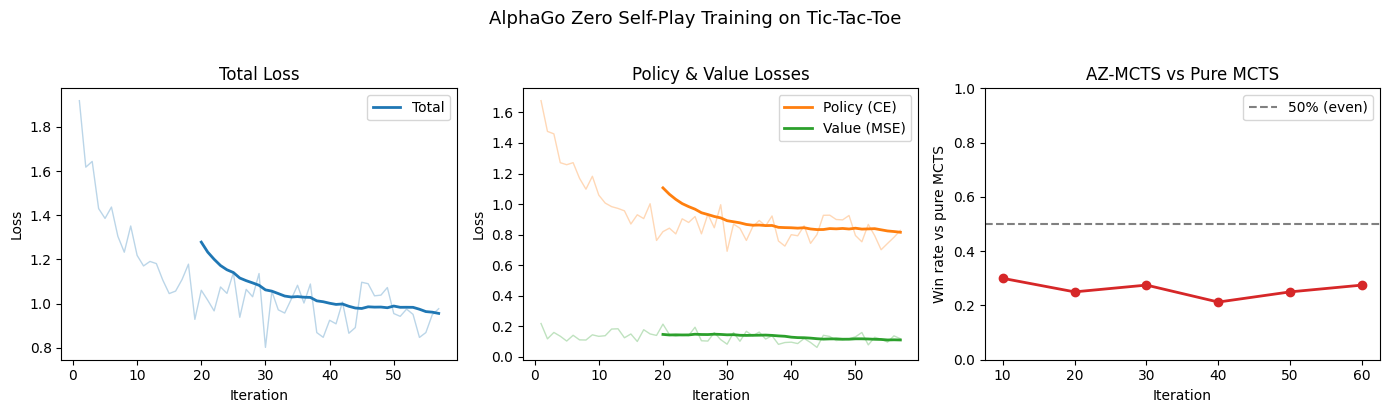

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

def plot_smooth(ax, xs, ys, **kwargs):
    s = smooth(ys)
    ax.plot(xs[len(xs) - len(s):], s, **kwargs)

# ── Loss curves ──────────────────────────────────────────────────────────────
ax = axes[0]
xs = np.arange(1, len(loss_history) + 1)
ax.plot(xs, loss_history,        alpha=0.3, color='C0', lw=1)
plot_smooth(ax, xs, loss_history, color='C0', lw=2, label='Total')
ax.set_xlabel('Iteration'); ax.set_ylabel('Loss')
ax.set_title('Total Loss'); ax.legend()

# ── Policy vs Value loss ──────────────────────────────────────────────────────
ax = axes[1]
ax.plot(xs, policy_loss_history, alpha=0.3, color='C1', lw=1)
plot_smooth(ax, xs, policy_loss_history, color='C1', lw=2, label='Policy (CE)')
ax.plot(xs, value_loss_history,  alpha=0.3, color='C2', lw=1)
plot_smooth(ax, xs, value_loss_history,  color='C2', lw=2, label='Value (MSE)')
ax.set_xlabel('Iteration'); ax.set_ylabel('Loss')
ax.set_title('Policy & Value Losses'); ax.legend()

# ── Win rate ──────────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(eval_iters, eval_winrates, '-o', color='C3', lw=2, ms=6)
ax.axhline(0.5, ls='--', color='gray', label='50% (even)')
ax.set_ylim(0, 1); ax.set_xlabel('Iteration')
ax.set_ylabel('Win rate vs pure MCTS')
ax.set_title('AZ-MCTS vs Pure MCTS'); ax.legend()

plt.suptitle('AlphaGo Zero Self-Play Training on Tic-Tac-Toe', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

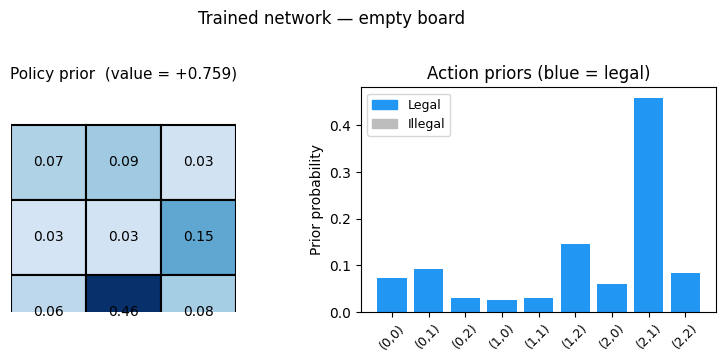

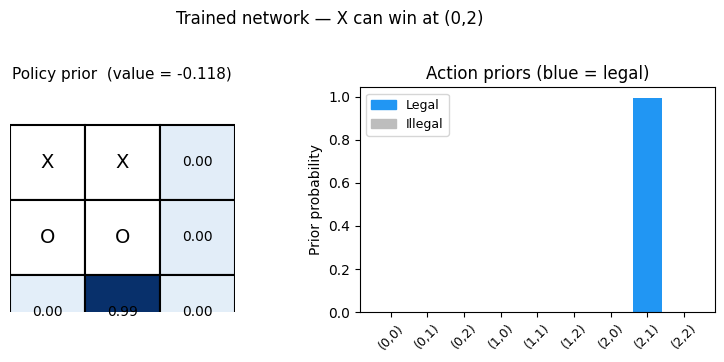

In [10]:
# ─── Visualise what the trained network has learned ───────────────────────────

def plot_network_output(net, board, title=''):
    """Show policy prior and value estimate for a given board position."""
    priors, value = net.predict(board)
    legal = np.where(board == 0)[0]
    masked = np.zeros(9)
    masked[legal] = priors[legal]
    if masked.sum() > 0:
        masked /= masked.sum()

    fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

    # Board + policy prior
    ax = axes[0]
    ax.set_xlim(-0.5, 2.5); ax.set_ylim(-0.5, 2.5)
    ax.set_aspect('equal'); ax.axis('off')
    for r in range(3):
        for c in range(3):
            idx = r * 3 + c
            sym = {1: 'X', -1: 'O', 0: ''}[int(board[idx])]
            prob = masked[idx]
            color = plt.cm.Blues(prob * 3 + 0.1) if prob > 0 else 'white'
            ax.add_patch(plt.Rectangle((c - 0.5, 1.5 - r - 0.5), 1, 1,
                                       facecolor=color, edgecolor='black', lw=1.5))
            ax.text(c, 1.5 - r, sym if sym else f'{prob:.2f}',
                    ha='center', va='center', fontsize=14 if sym else 10)
    ax.set_title(f'Policy prior  (value = {value:+.3f})', fontsize=11)

    # Bar chart of prior probabilities
    ax = axes[1]
    colors = ['#2196F3' if i in legal else '#BDBDBD' for i in range(9)]
    ax.bar(range(9), masked, color=colors)
    ax.set_xticks(range(9))
    ax.set_xticklabels([f'({i//3},{i%3})' for i in range(9)], rotation=45, fontsize=9)
    ax.set_ylabel('Prior probability')
    ax.set_title('Action priors (blue = legal)')
    legal_patch  = mpatches.Patch(color='#2196F3', label='Legal')
    illegal_patch = mpatches.Patch(color='#BDBDBD', label='Illegal')
    ax.legend(handles=[legal_patch, illegal_patch], fontsize=9)

    plt.suptitle(title, fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


# Empty board — should assign roughly equal priors with a slight centre preference
plot_network_output(net, np.zeros(9, dtype=np.float32),
                    title='Trained network — empty board')

# Forced win in one move — should spike at action 2
board_win = np.array([1, 1, 0, -1, -1, 0, 0, 0, 0], dtype=np.float32)
plot_network_output(net, board_win,
                    title='Trained network — X can win at (0,2)')

## 7 — Summary

### AlphaGo Zero design choices and why they work

| Component | Role | Key insight |
|-----------|------|-------------|
| **Dual network** | Actor (policy) + Critic (value) share a trunk | Joint training stabilises both heads; shared representation amortises computation |
| **PUCT selection** | Exploration bonus scaled by prior $P(s,a)$ | Better initialisation of unexplored nodes; policy network guides search toward promising regions |
| **No rollouts** | Network value replaces Monte Carlo simulation | Eliminates high-variance estimates; network learns to generalise across positions |
| **MCTS as policy improvement** | Visit counts $\pi$ are used as training targets | MCTS is a *lookahead* operator that provably improves over the raw network policy |
| **Self-play** | Data generated by current best network | Curriculum adapts automatically; no human data required |
| **Dirichlet noise at root** | Adds randomness to root priors | Ensures exploration of all legal moves during training |

### Connection to the actor-critic framework

| A2C / A3C | AlphaGo Zero |
|-----------|-------------|
| Actor: $\pi_\theta(a|s)$ | Policy head: $\mathbf{p}_\theta(s)$ |
| Critic: $V_\theta(s)$ | Value head: $v_\theta(s)$ |
| Policy gradient: $\nabla \log \pi \cdot A$ | Policy target: MCTS visit counts $\pi$ |
| TD bootstrap target | Self-play game outcome $z$ |
| Entropy bonus for exploration | Dirichlet noise + temperature |

The key innovation of AlphaGo Zero is replacing the **TD-trained critic** with
a **MCTS-informed critic** and replacing **vanilla policy gradient** with
**MCTS-improved policy supervision**.  MCTS bridges the gap between single-step
actor-critic updates and optimal lookahead planning.

### The AlphaGo family

| Paper | Key change |
|-------|------------|
| **AlphaGo** (2016) | Separate SL policy, RL policy, value net + rollout policy; trained on human games |
| **AlphaGo Zero** (2017) | Single dual-headed network; no human data; residual architecture |
| **AlphaZero** (2018) | Same algorithm, applied to Chess and Shogi without domain-specific tuning |
| **MuZero** (2019) | Learns a *latent world model* — MCTS without knowing the rules in advance |